# Previsão de Sobrevivência de Pacientes com Cirrose Hepática
### Disciplina: Inteligência de Negócios - 2026/1 - Profa Kelly
Técnicas de classificação: KNN, Random Forest e XGBoost  
Experimentos: Base Desbalanceada vs. Base com SMOTE

## 1. Importações e Configuração

In [12]:
import os
import warnings
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Download e Carregamento do Dataset

In [13]:
# Download automático do dataset da UCI
DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/878/"
    "cirrhosis+patient+survival+prediction+dataset-1.zip"
)
ZIP_PATH = "cirrhosis.zip"
EXTRACT_DIR = "cirrhosis_data"
CSV_NAME = "cirrhosis.csv"


def download_dataset():
    """Baixa e extrai o dataset se ainda não estiver presente."""
    csv_path = os.path.join(EXTRACT_DIR, CSV_NAME)
    if os.path.exists(csv_path):
        print(f"Dataset já encontrado em: {csv_path}")
        return csv_path

    if not os.path.exists(ZIP_PATH):
        print("Baixando dataset da UCI...")
        headers = {"User-Agent": "Mozilla/5.0"}
        req = urllib.request.Request(DATASET_URL, headers=headers)
        with urllib.request.urlopen(req) as resp, open(ZIP_PATH, "wb") as out:
            out.write(resp.read())
        print("Download concluído.")

    print("Extraindo arquivos...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    # Localiza o CSV dentro do zip (pode haver subpastas)
    for root, _, files in os.walk(EXTRACT_DIR):
        for f in files:
            if f.lower().endswith(".csv"):
                full = os.path.join(root, f)
                print(f"CSV encontrado: {full}")
                return full

    raise FileNotFoundError("CSV não encontrado após extração.")


csv_path = download_dataset()
df_raw = pd.read_csv(csv_path)
print(f"\nShape do dataset: {df_raw.shape}")
print(df_raw.head())

Dataset já encontrado em: cirrhosis_data\cirrhosis.csv

Shape do dataset: (418, 20)
   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48   210.0     516.0   96.10   
3     S        1.8        244.0     2.54    64.0    6121.8   60.63   
4     N        3.4        279.0     3.53   143.0     671.0  113.15   

   Trygl

## 3. Análise Exploratória Inicial

In [14]:
print("=== Informações Gerais ===")
print(df_raw.info())

print("\n=== Valores Nulos por Coluna ===")
print(df_raw.isnull().sum())

print("\n=== Distribuição da Variável Alvo (Status) ===")
print(df_raw["Status"].value_counts())
print(df_raw["Status"].value_counts(normalize=True).round(3) * 100)

=== Informações Gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null

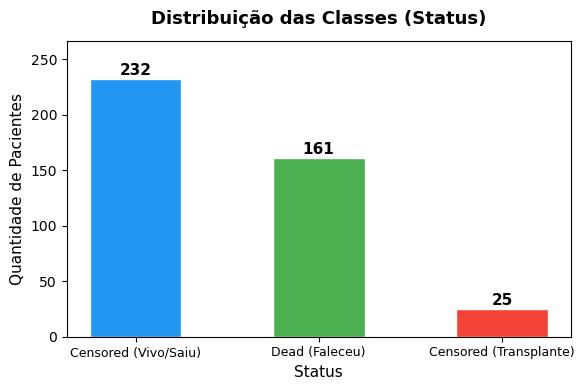

Gráfico salvo: distribuicao_classes.png


In [15]:
# Visualização da distribuição do alvo
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_raw["Status"].value_counts()
colors = ["#2196F3", "#4CAF50", "#F44336"]
bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Distribuição das Classes (Status)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Status", fontsize=11)
ax.set_ylabel("Quantidade de Pacientes", fontsize=11)
ax.set_ylim(0, counts.max() * 1.15)
legend_labels = {"C": "Censored (Vivo/Saiu)", "CL": "Censored (Transplante)", "D": "Dead (Faleceu)"}
ax.set_xticklabels([legend_labels.get(x, x) for x in counts.index], fontsize=9)
plt.tight_layout()
plt.savefig("distribuicao_classes.png", dpi=150)
plt.show()
print("Gráfico salvo: distribuicao_classes.png")

## 4. Pré-processamento

In [16]:
df = df_raw.copy()

# 4.1 Remover a coluna ID (não informativa)
if "ID" in df.columns:
    df.drop(columns=["ID"], inplace=True)

# 4.2 Remover registros sem Status definido
df = df[df["Status"].notna()].copy()

# 4.3 Codificar a variável alvo
# C  -> 0 (Censored - vivo ou saiu do estudo)
# CL -> 1 (Censored due to liver transplant)
# D  -> 2 (Dead - faleceu)
status_map = {"C": 0, "CL": 1, "D": 2}
df["Status"] = df["Status"].map(status_map)

print("Distribuição após mapeamento:")
print(df["Status"].value_counts().sort_index())
print({v: k for k, v in status_map.items()})

Distribuição após mapeamento:
Status
0    232
1     25
2    161
Name: count, dtype: int64
{0: 'C', 1: 'CL', 2: 'D'}


In [17]:
# 4.4 Separar features e target
y = df["Status"].values
X = df.drop(columns=["Status"])

print(f"\nFeatures: {X.shape[1]} colunas")
print(f"Amostras: {X.shape[0]}")


Features: 18 colunas
Amostras: 418


In [18]:
# 4.5 Identificar colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"\nColunas categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Colunas numéricas  ({len(num_cols)}): {num_cols}")


Colunas categóricas (6): ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
Colunas numéricas  (12): ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [19]:
# 4.6 Encodar variáveis categóricas com LabelEncoder
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Preencher NaN com string temporária para o encoder
    X[col] = X[col].fillna("Desconhecido")
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# 4.7 Preencher valores nulos numéricos com a mediana
for col in num_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print("\nValores nulos restantes:", X.isnull().sum().sum())
print("Shape final de X:", X.shape)


Valores nulos restantes: 0
Shape final de X: (418, 18)


In [20]:
# 4.8 Divisão treino/teste: 70% / 30% (mesmo split para todos os experimentos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste : {X_test.shape[0]} amostras")
print("\nDistribuição no treino:", np.bincount(y_train))
print("Distribuição no teste :", np.bincount(y_test))

Treino: 292 amostras
Teste : 126 amostras

Distribuição no treino: [162  17 113]
Distribuição no teste : [70  8 48]


In [21]:
# 4.9 Normalização (StandardScaler) - ajuste somente no treino
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 5. Funções Auxiliares

In [22]:
def avaliar_modelo(nome, y_true, y_pred, classes=None, ax=None):
    """Calcula e exibe métricas de desempenho e matriz de confusão."""
    if classes is None:
        classes = ["C (0)", "CL (1)", "D (2)"]

    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  Modelo: {nome}")
    print(f"{'='*55}")
    print(f"  Precisão  (weighted): {prec:.4f}")
    print(f"  Revocação (weighted): {rec:.4f}")
    print(f"  F1-Score  (weighted): {f1:.4f}")
    print(f"\n  Relatório por Classe:")
    print(classification_report(y_true, y_pred,
                                 target_names=classes, zero_division=0))
    print(f"  Matriz de Confusão:\n{cm}")

    if ax is not None:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(nome, fontsize=10, fontweight="bold")

    return {"modelo": nome, "precisao": prec, "revocacao": rec, "f1": f1}


def plotar_matrizes(resultados_plot, titulo_figura, filename):
    """Plota as matrizes de confusão dos 3 modelos lado a lado."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(titulo_figura, fontsize=13, fontweight="bold", y=1.02)
    for ax, (nome, y_true, y_pred) in zip(axes, resultados_plot):
        classes = ["C (0)", "CL (1)", "D (2)"]
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(nome, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Gráfico salvo: {filename}")


def plotar_comparacao(df_metricas, titulo, filename):
    """Plota gráfico comparativo das métricas entre os modelos."""
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(df_metricas))
    width = 0.25
    b1 = ax.bar(x - width, df_metricas["precisao"],  width, label="Precisão",  color="#2196F3")
    b2 = ax.bar(x,          df_metricas["revocacao"], width, label="Revocação", color="#4CAF50")
    b3 = ax.bar(x + width,  df_metricas["f1"],        width, label="F1-Score",  color="#FF9800")

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(df_metricas["modelo"], fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Valor da Métrica", fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Gráfico salvo: {filename}")

## 6. Experimento 1 — Base Desbalanceada (Original)

In [23]:
print("\n" + "="*60)
print("  EXPERIMENTO 1: Base Desbalanceada (Original)")
print("="*60)

metricas_exp1 = []
preds_exp1 = []

# --- 6.1 KNN ---
print("\n[Treinando KNN...]")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
metricas_exp1.append(avaliar_modelo("KNN (Exp. 1)", y_test, y_pred_knn))
preds_exp1.append(("KNN", y_test, y_pred_knn))

# --- 6.2 Random Forest ---
print("\n[Treinando Random Forest...]")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
metricas_exp1.append(avaliar_modelo("Random Forest (Exp. 1)", y_test, y_pred_rf))
preds_exp1.append(("Random Forest", y_test, y_pred_rf))

# --- 6.3 XGBoost ---
print("\n[Treinando XGBoost...]")
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train_sc, y_train)
y_pred_xgb = xgb.predict(X_test_sc)
metricas_exp1.append(avaliar_modelo("XGBoost (Exp. 1)", y_test, y_pred_xgb))
preds_exp1.append(("XGBoost", y_test, y_pred_xgb))


  EXPERIMENTO 1: Base Desbalanceada (Original)

[Treinando KNN...]

  Modelo: KNN (Exp. 1)
  Precisão  (weighted): 0.6438
  Revocação (weighted): 0.6587
  F1-Score  (weighted): 0.6307

  Relatório por Classe:
              precision    recall  f1-score   support

       C (0)       0.66      0.87      0.75        70
      CL (1)       0.00      0.00      0.00         8
       D (2)       0.73      0.46      0.56        48

    accuracy                           0.66       126
   macro avg       0.46      0.44      0.44       126
weighted avg       0.64      0.66      0.63       126

  Matriz de Confusão:
[[61  2  7]
 [ 7  0  1]
 [25  1 22]]

[Treinando Random Forest...]

  Modelo: Random Forest (Exp. 1)
  Precisão  (weighted): 0.7160
  Revocação (weighted): 0.7619
  F1-Score  (weighted): 0.7339

  Relatório por Classe:
              precision    recall  f1-score   support

       C (0)       0.75      0.90      0.82        70
      CL (1)       0.00      0.00      0.00         8
     

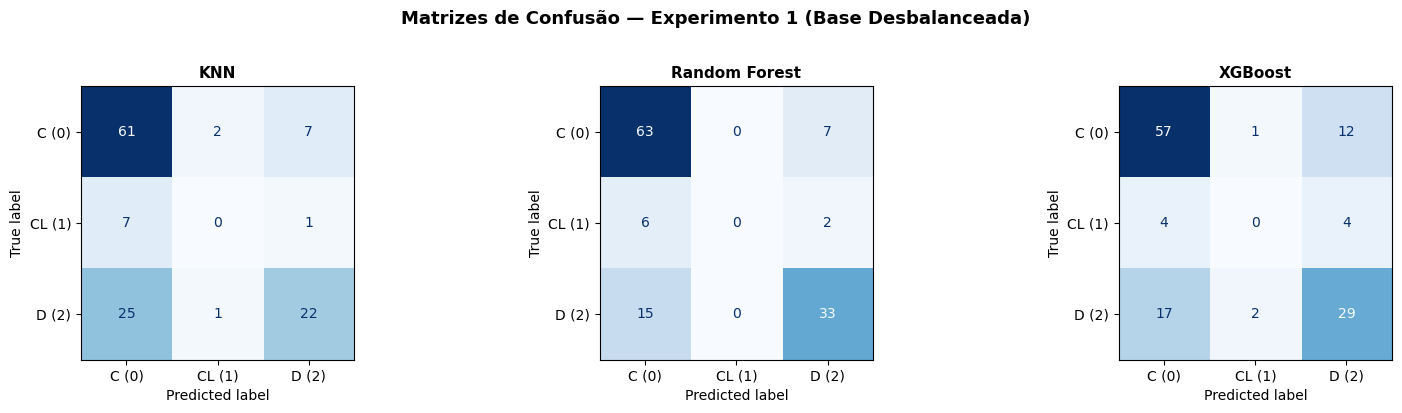

Gráfico salvo: matrizes_exp1.png


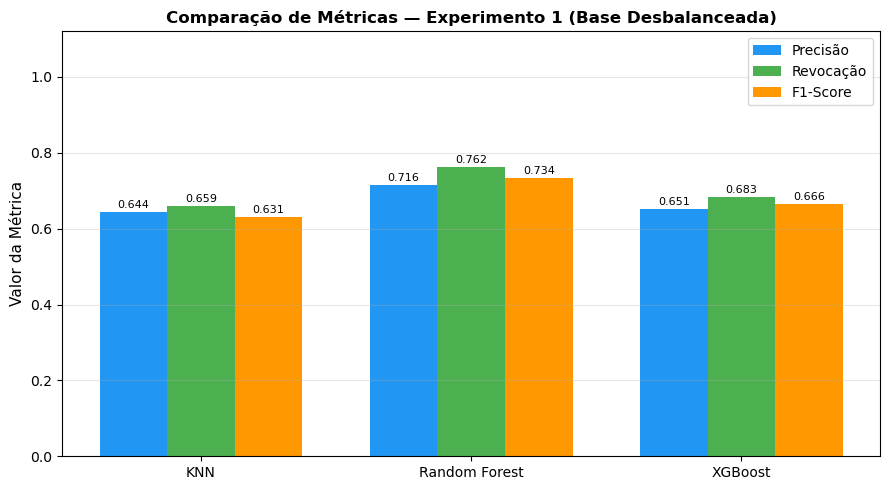

Gráfico salvo: metricas_exp1.png

Tabela resumo — Experimento 1:
       modelo  precisao  revocacao       f1
          KNN  0.643762   0.658730 0.630711
Random Forest  0.715986   0.761905 0.733911
      XGBoost  0.651486   0.682540 0.665511


In [24]:
# Visualizações do Experimento 1
df_metricas_exp1 = pd.DataFrame(metricas_exp1)
df_metricas_exp1["modelo"] = ["KNN", "Random Forest", "XGBoost"]

plotar_matrizes(preds_exp1,
                "Matrizes de Confusão — Experimento 1 (Base Desbalanceada)",
                "matrizes_exp1.png")

plotar_comparacao(df_metricas_exp1,
                  "Comparação de Métricas — Experimento 1 (Base Desbalanceada)",
                  "metricas_exp1.png")

print("\nTabela resumo — Experimento 1:")
print(df_metricas_exp1.to_string(index=False))

## 7. Experimento 2 — Base Balanceada com SMOTE

In [25]:
print("\n" + "="*60)
print("  EXPERIMENTO 2: SMOTE aplicado apenas no Treino")
print("="*60)

# Aplicar SMOTE somente nos dados de TREINO
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"\nAntes do SMOTE — Treino: {np.bincount(y_train)}")
print(f"Após  o SMOTE — Treino: {np.bincount(y_train_sm)}")
print(f"(Conjunto de TESTE permanece inalterado: {np.bincount(y_test)})")


  EXPERIMENTO 2: SMOTE aplicado apenas no Treino

Antes do SMOTE — Treino: [162  17 113]
Após  o SMOTE — Treino: [162 162 162]
(Conjunto de TESTE permanece inalterado: [70  8 48])


In [26]:
metricas_exp2 = []
preds_exp2 = []

# --- 7.1 KNN com SMOTE ---
print("\n[Treinando KNN com SMOTE...]")
knn_sm = KNeighborsClassifier(n_neighbors=5)
knn_sm.fit(X_train_sm, y_train_sm)
y_pred_knn_sm = knn_sm.predict(X_test_sc)
metricas_exp2.append(avaliar_modelo("KNN (SMOTE)", y_test, y_pred_knn_sm))
preds_exp2.append(("KNN + SMOTE", y_test, y_pred_knn_sm))

# --- 7.2 Random Forest com SMOTE ---
print("\n[Treinando Random Forest com SMOTE...]")
rf_sm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_sm.predict(X_test_sc)
metricas_exp2.append(avaliar_modelo("Random Forest (SMOTE)", y_test, y_pred_rf_sm))
preds_exp2.append(("Random Forest + SMOTE", y_test, y_pred_rf_sm))

# --- 7.3 XGBoost com SMOTE ---
print("\n[Treinando XGBoost com SMOTE...]")
xgb_sm = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
xgb_sm.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_sm.predict(X_test_sc)
metricas_exp2.append(avaliar_modelo("XGBoost (SMOTE)", y_test, y_pred_xgb_sm))
preds_exp2.append(("XGBoost + SMOTE", y_test, y_pred_xgb_sm))


[Treinando KNN com SMOTE...]

  Modelo: KNN (SMOTE)
  Precisão  (weighted): 0.6720
  Revocação (weighted): 0.5873
  F1-Score  (weighted): 0.6200

  Relatório por Classe:
              precision    recall  f1-score   support

       C (0)       0.72      0.69      0.70        70
      CL (1)       0.08      0.25      0.12         8
       D (2)       0.71      0.50      0.59        48

    accuracy                           0.59       126
   macro avg       0.50      0.48      0.47       126
weighted avg       0.67      0.59      0.62       126

  Matriz de Confusão:
[[48 14  8]
 [ 4  2  2]
 [15  9 24]]

[Treinando Random Forest com SMOTE...]

  Modelo: Random Forest (SMOTE)
  Precisão  (weighted): 0.7055
  Revocação (weighted): 0.6984
  F1-Score  (weighted): 0.6982

  Relatório por Classe:
              precision    recall  f1-score   support

       C (0)       0.77      0.84      0.80        70
      CL (1)       0.10      0.12      0.11         8
       D (2)       0.72      0.58  

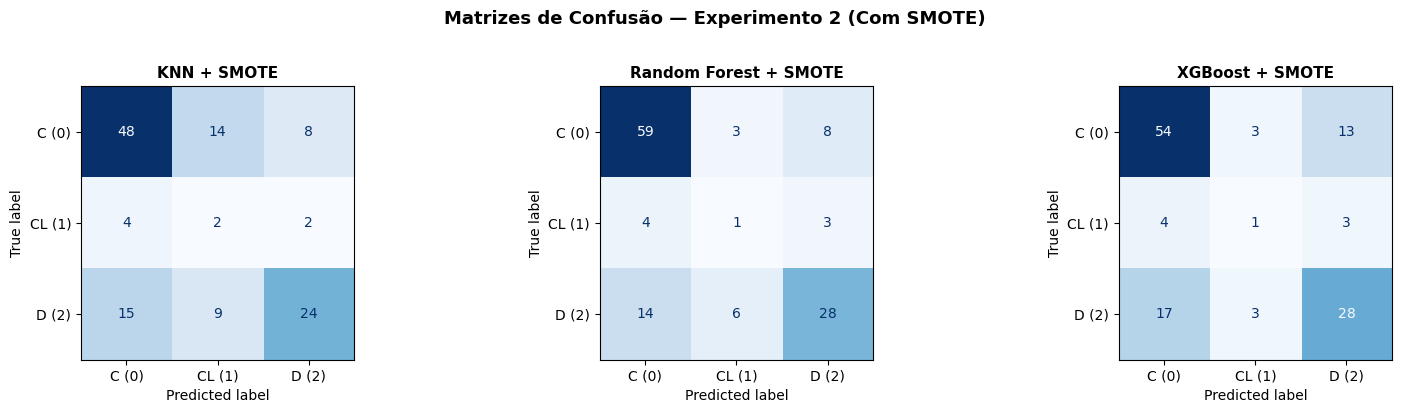

Gráfico salvo: matrizes_exp2.png


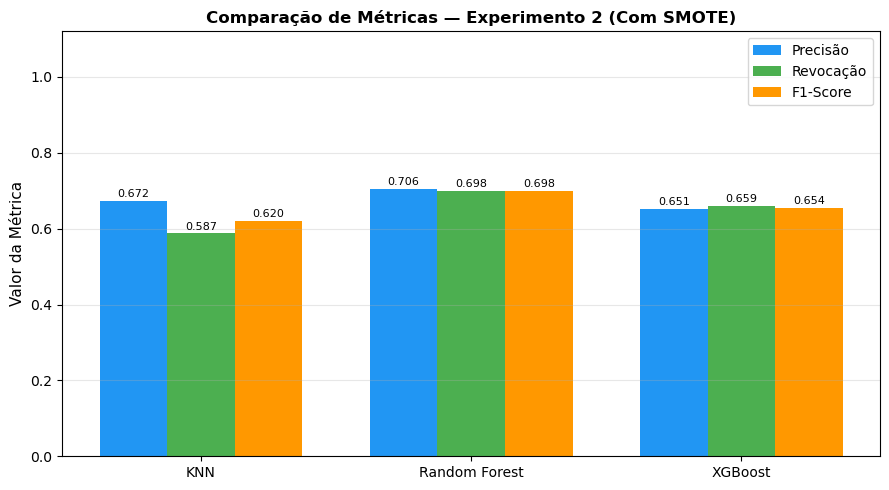

Gráfico salvo: metricas_exp2.png

Tabela resumo — Experimento 2:
       modelo  precisao  revocacao       f1
          KNN  0.671997   0.587302 0.619987
Random Forest  0.705539   0.698413 0.698222
      XGBoost  0.651495   0.658730 0.654143


In [27]:
# Visualizações do Experimento 2
df_metricas_exp2 = pd.DataFrame(metricas_exp2)
df_metricas_exp2["modelo"] = ["KNN", "Random Forest", "XGBoost"]

plotar_matrizes(preds_exp2,
                "Matrizes de Confusão — Experimento 2 (Com SMOTE)",
                "matrizes_exp2.png")

plotar_comparacao(df_metricas_exp2,
                  "Comparação de Métricas — Experimento 2 (Com SMOTE)",
                  "metricas_exp2.png")

print("\nTabela resumo — Experimento 2:")
print(df_metricas_exp2.to_string(index=False))

## 8. Comparação Geral entre os Dois Experimentos


  COMPARAÇÃO GERAL: Experimento 1 vs. Experimento 2


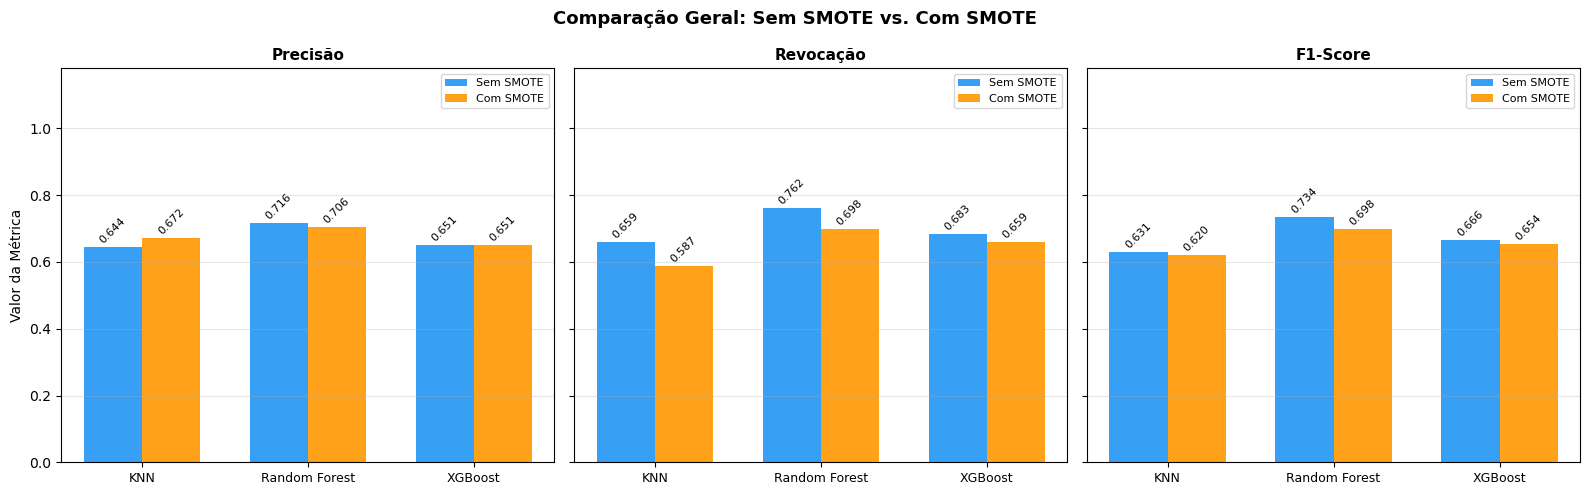

Gráfico salvo: comparacao_geral.png


In [28]:
print("\n" + "="*60)
print("  COMPARAÇÃO GERAL: Experimento 1 vs. Experimento 2")
print("="*60)

modelos = ["KNN", "Random Forest", "XGBoost"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metricas_nomes = ["precisao", "revocacao", "f1"]
metricas_labels = ["Precisão", "Revocação", "F1-Score"]
cores = ["#2196F3", "#FF9800"]

for i, (metrica, label) in enumerate(zip(metricas_nomes, metricas_labels)):
    ax = axes[i]
    x = np.arange(len(modelos))
    v1 = df_metricas_exp1[metrica].values
    v2 = df_metricas_exp2[metrica].values
    width = 0.35
    b1 = ax.bar(x - width/2, v1, width, label="Sem SMOTE", color=cores[0], alpha=0.9)
    b2 = ax.bar(x + width/2, v2, width, label="Com SMOTE", color=cores[1], alpha=0.9)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8, rotation=45)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.grid(axis="y", alpha=0.3)
    if i == 0:
        ax.set_ylabel("Valor da Métrica", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Comparação Geral: Sem SMOTE vs. Com SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacao_geral.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: comparacao_geral.png")

In [29]:
# Tabela comparativa consolidada
df_comp = pd.DataFrame({
    "Modelo": modelos * 2,
    "Experimento": ["Sem SMOTE"] * 3 + ["Com SMOTE"] * 3,
    "Precisão":  list(df_metricas_exp1["precisao"]) + list(df_metricas_exp2["precisao"]),
    "Revocação": list(df_metricas_exp1["revocacao"]) + list(df_metricas_exp2["revocacao"]),
    "F1-Score":  list(df_metricas_exp1["f1"])        + list(df_metricas_exp2["f1"]),
})

print("\nTabela Comparativa Consolidada:")
print(df_comp.to_string(index=False))


Tabela Comparativa Consolidada:
       Modelo Experimento  Precisão  Revocação  F1-Score
          KNN   Sem SMOTE  0.643762   0.658730  0.630711
Random Forest   Sem SMOTE  0.715986   0.761905  0.733911
      XGBoost   Sem SMOTE  0.651486   0.682540  0.665511
          KNN   Com SMOTE  0.671997   0.587302  0.619987
Random Forest   Com SMOTE  0.705539   0.698413  0.698222
      XGBoost   Com SMOTE  0.651495   0.658730  0.654143


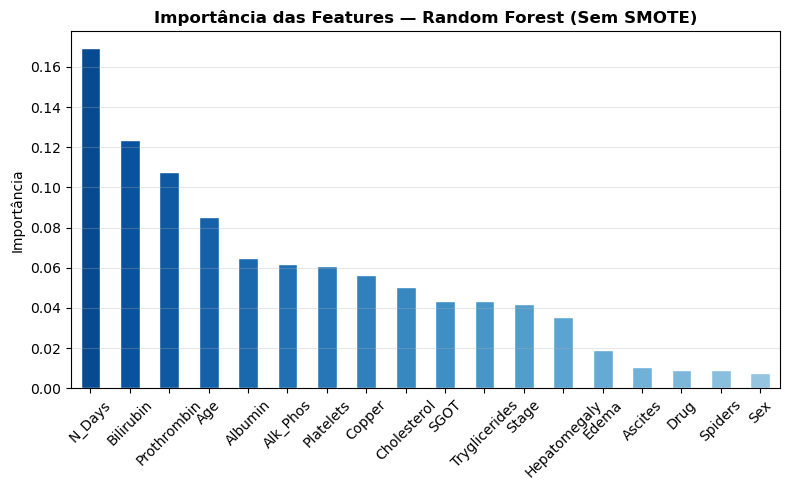

Gráfico salvo: feature_importance.png


In [30]:
# Importância de features (Random Forest — Experimento 1)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(feat_imp)))[::-1]
feat_imp.plot(kind="bar", ax=ax, color=colors_fi, edgecolor="white")
ax.set_title("Importância das Features — Random Forest (Sem SMOTE)", fontsize=12, fontweight="bold")
ax.set_ylabel("Importância", fontsize=10)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Gráfico salvo: feature_importance.png")

## 9. Considerações Finais

In [31]:
print("\n" + "="*60)
print("  RESUMO FINAL DOS RESULTADOS")
print("="*60)
print(df_comp.to_string(index=False))

print("\n" + "="*60)
print("  MELHOR MODELO POR F1-SCORE")
print("="*60)
melhor_exp1 = df_metricas_exp1.loc[df_metricas_exp1["f1"].idxmax()]
melhor_exp2 = df_metricas_exp2.loc[df_metricas_exp2["f1"].idxmax()]
print(f"  Exp. 1 (Sem SMOTE): {melhor_exp1['modelo']}  — F1={melhor_exp1['f1']:.4f}")
print(f"  Exp. 2 (Com SMOTE): {melhor_exp2['modelo']}  — F1={melhor_exp2['f1']:.4f}")
print("\nProcessamento concluído com sucesso!")


  RESUMO FINAL DOS RESULTADOS
       Modelo Experimento  Precisão  Revocação  F1-Score
          KNN   Sem SMOTE  0.643762   0.658730  0.630711
Random Forest   Sem SMOTE  0.715986   0.761905  0.733911
      XGBoost   Sem SMOTE  0.651486   0.682540  0.665511
          KNN   Com SMOTE  0.671997   0.587302  0.619987
Random Forest   Com SMOTE  0.705539   0.698413  0.698222
      XGBoost   Com SMOTE  0.651495   0.658730  0.654143

  MELHOR MODELO POR F1-SCORE
  Exp. 1 (Sem SMOTE): Random Forest  — F1=0.7339
  Exp. 2 (Com SMOTE): Random Forest  — F1=0.6982

Processamento concluído com sucesso!
